In [ ]:
#! pip install PyMuPDF

  Using cached pymupdf-1.26.6-cp310-abi3-manylinux_2_28_x86_64.whl.metadata (3.4 kB)
Using cached pymupdf-1.26.6-cp310-abi3-manylinux_2_28_x86_64.whl (24.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import torch
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from pathlib import Path
from typing import List, Optional, Union
from tqdm import tqdm
import matplotlib.pyplot as plt
import fitz  # PyMuPDF
from io import BytesIO

import supervision as sv
import torchvision.transforms as T

In [ ]:
# Paths and config
REPO_ROOT = "/home/abuzayed.a/D-FINE"
sys.path.append(REPO_ROOT)
from src.core import YAMLConfig


# Model wrapper
class DFineDeployModel(torch.nn.Module):
    def __init__(self, cfg: YAMLConfig):
        super().__init__()
        self.model = cfg.model.deploy()
        self.postprocessor = cfg.postprocessor.deploy()

    @torch.no_grad()
    def forward(self, images: torch.Tensor, orig_target_sizes: torch.Tensor):
        outputs = self.model(images)
        return self.postprocessor(outputs, orig_target_sizes)


# Load model + checkpoint
def load_dfine(config_path, ckpt_path, device="cuda:0"):
    cfg = YAMLConfig(config_path, resume=ckpt_path)

    checkpoint = torch.load(ckpt_path, map_location="cpu")
    if "ema" in checkpoint:
        state = checkpoint["ema"]["module"]
    elif "model" in checkpoint:
        state = checkpoint["model"]
    elif "state_dict" in checkpoint:
        state = checkpoint["state_dict"]
    else:
        state = checkpoint
    cfg.model.load_state_dict(state, strict=True)

    model = DFineDeployModel(cfg).to(device).eval()
    return model


# Visualization helper
def draw_boxes(classes_, img, det: sv.Detections, color, show_conf: bool = False):
    out = img.copy()
    for i, (x1, y1, x2, y2) in enumerate(det.xyxy.astype(int)):
        cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness=2)
        if show_conf:
            cls_name = classes_[int(det.class_id[i])] if det.class_id is not None else "?"
            conf = float(det.confidence[i]) if det.confidence is not None else 1.0
            text = f"{cls_name} {conf:.2f}"
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            y_text = max(y1 - 5, th + 2)
            cv2.rectangle(out, (x1, y_text - th - 2), (x1 + tw, y_text), color, -1)
            cv2.putText(out, text, (x1, y_text - 2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255),
                        1, cv2.LINE_AA)
    return out


# visualization
def visualize_predictions(img, boxes, labels, scores, classes=None):
    img_np = np.array(img)
    img_cv = img_np[:, :, ::-1].copy()  # RGB -> BGR

    det = sv.Detections(
        xyxy=np.array(boxes, dtype=np.float32),
        class_id=np.array(labels, dtype=np.int32),
        confidence=np.array(scores, dtype=np.float32),
    )

    vis = draw_boxes(
        classes_ = classes or [str(i) for i in range(999)],
        img = img_cv,
        det = det,
        color = (0, 0, 255),
        show_conf=True,
    )

    vis_rgb = vis[:, :, ::-1]  # back to RGB

    plt.figure(figsize=(10, 12))
    plt.imshow(vis_rgb)
    plt.axis("off")
    plt.show()


# Convert PDF pages to PIL images (selected pages allowed)
def pdf_to_images(pdf_path, pages="all", dpi=200):
    """
    Convert selected PDF pages into PIL images.
    pages: "all", int, list[int]
    Returns: list of (page_number, PIL.Image)
    """
    doc = fitz.open(pdf_path)

    # Normalize pages
    if pages == "all":
        page_indices = list(range(len(doc)))
    elif isinstance(pages, int):
        page_indices = [pages]
    elif isinstance(pages, (list, tuple)):
        page_indices = list(pages)
    else:
        raise ValueError("pages must be 'all', int, or list[int]")

    out = []
    for p in page_indices:
        if p >= len(doc):
            print(f" Page {p} out of range. Skipping.")
            continue
        page = doc[p]
        pix = page.get_pixmap(dpi=dpi)
        img = Image.open(BytesIO(pix.tobytes("png"))).convert("RGB")
        out.append((p, img))
    return out


# D-FINE inference on PDF pages
def run_dfine_on_pdf(model, pdf_path, pages="all", device="cuda:0", conf_thr=0.5, dpi=200):
    """
    Run D-FINE inference on selected PDF pages and visualize.
    """
    pages_imgs = pdf_to_images(pdf_path, pages=pages, dpi=dpi)
    tfm = T.Compose([T.Resize((640, 640)), T.ToTensor()])

    all_results = []

    for page_idx, pil_img in pages_imgs:
        img_tensor = tfm(pil_img).unsqueeze(0).to(device)
        orig_size = torch.tensor([[pil_img.size[0], pil_img.size[1]]], device=device)

        labels_list, boxes_list, scores_list = model(img_tensor, orig_size)

        labels = labels_list[0].cpu().numpy()
        boxes = boxes_list[0].cpu().numpy()
        scores = scores_list[0].cpu().numpy()

        keep = scores >= conf_thr

        result = {
            "page": page_idx,
            "labels": labels[keep].tolist(),
            "boxes": boxes[keep].tolist(),
            "scores": scores[keep].tolist(),
        }
        all_results.append(result)

        #  visualization
        visualize_predictions(
            pil_img,
            boxes=result["boxes"],
            labels=result["labels"],
            scores=result["scores"],
        )

    return all_results


In [4]:
config = "/home/abuzayed.a/D-FINE/configs/dfine/dfine_hgnetv2_l_coco_layout.yml"
ckpt   = "/home/shared_storage/TalkToDocs-Ingest/models/layout/dfine_batch_0_1_2_3_4_5_6_7_8_doclaynet/best_stg1.pth"

device = "cuda:6"

model = load_dfine(config, ckpt, device=device)

If the pretrained HGNetV2 can't be downloaded automatically. Please check your network connection.
Please check your network connection. Or download the model manually from https://github.com/Peterande/storage/releases/download/dfinev1.0/PPHGNetV2_B4_stage1.pth to weight/hgnetv2/.
Loaded stage1 B4 HGNetV2 from URL.
Loaded stage1 B4 HGNetV2 from URL.


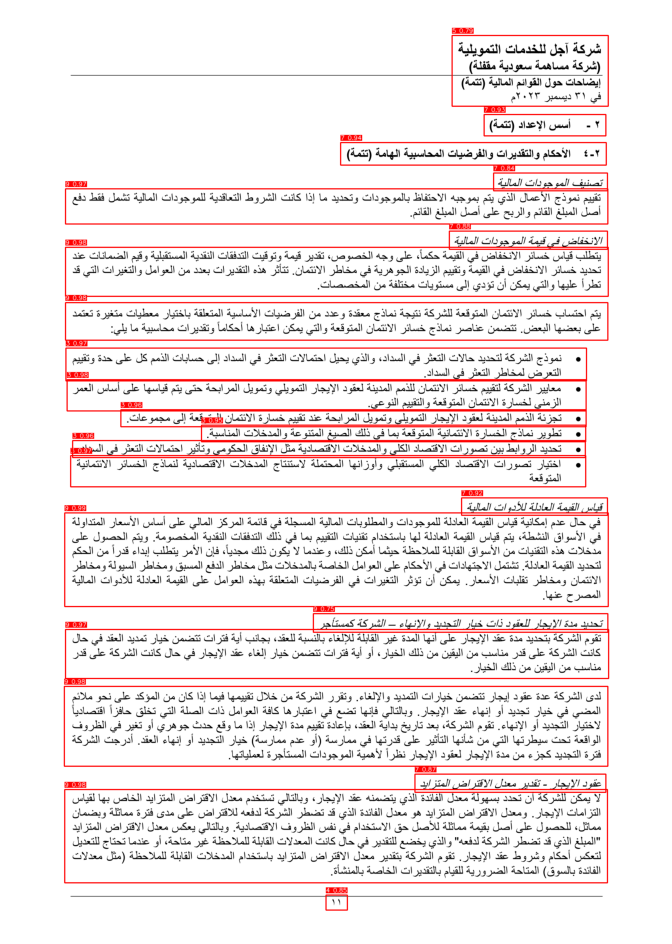

In [5]:
#pdf_path = "/home/abuzayed.a/data/fin_doc/4126_0_2025-05-13_10-34-17_Ar.pdf"
pdf_path = "/home/abuzayed.a/data/fin_doc/426_0_2021-11-11_08-04-56_Ar.pdf"
pdf_path = "/home/abuzayed.a/data/fin_doc/4926_0_2023-11-08_16-55-56_Ar.pdf"
pdf_path = "/home/shared_storage/TalkToDocs-Ingest/data/layout/cvat_batches/Batch9/docs/Ar/AJIL-Audit-Arabic-FS-31-December-2023_-004.pdf"
#results = run_dfine_on_pdf(model, pdf_path, pages="all", device=device)
results = run_dfine_on_pdf(model, pdf_path, pages=11, device=device, conf_thr=0.65)

In [8]:
results

[{'page': 0,
  'labels': [9, 7],
  'boxes': [[425.01348876953125,
    634.2424926757812,
    1209.7119140625,
    778.4020385742188],
   [612.7916259765625, 461.2247009277344, 1214.7724609375, 611.356689453125]],
  'scores': [0.8408299684524536, 0.7186978459358215]},
 {'page': 1,
  'labels': [9, 9, 9, 9, 9, 9, 9, 5, 9, 6, 7],
  'boxes': [[228.66262817382812,
    448.55828857421875,
    1511.7159423828125,
    504.62078857421875],
   [217.94631958007812,
    380.6188049316406,
    1511.396728515625,
    435.89312744140625],
   [228.75343322753906,
    659.6382446289062,
    1511.8333740234375,
    714.5455322265625],
   [203.07766723632812,
    801.5784301757812,
    1510.7293701171875,
    855.9180297851562],
   [228.2236785888672, 731.1103515625, 1511.3427734375, 784.2025146484375],
   [229.6731414794922, 590.4686279296875, 1511.8505859375, 646.0531616210938],
   [229.67066955566406,
    518.6649780273438,
    1511.176513671875,
    573.151611328125],
   [1093.886474609375, 67.3795394

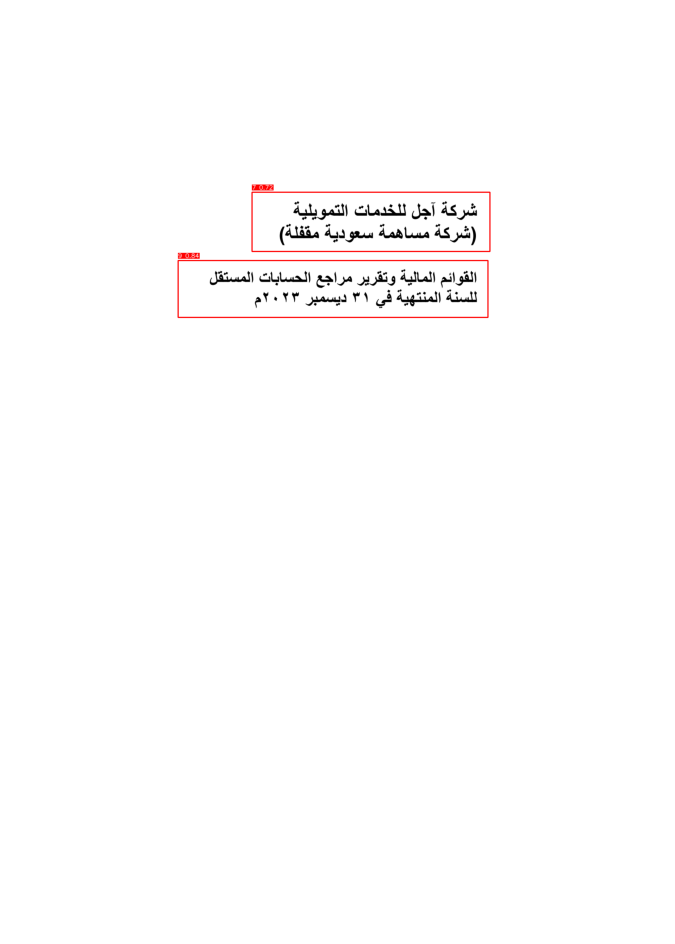

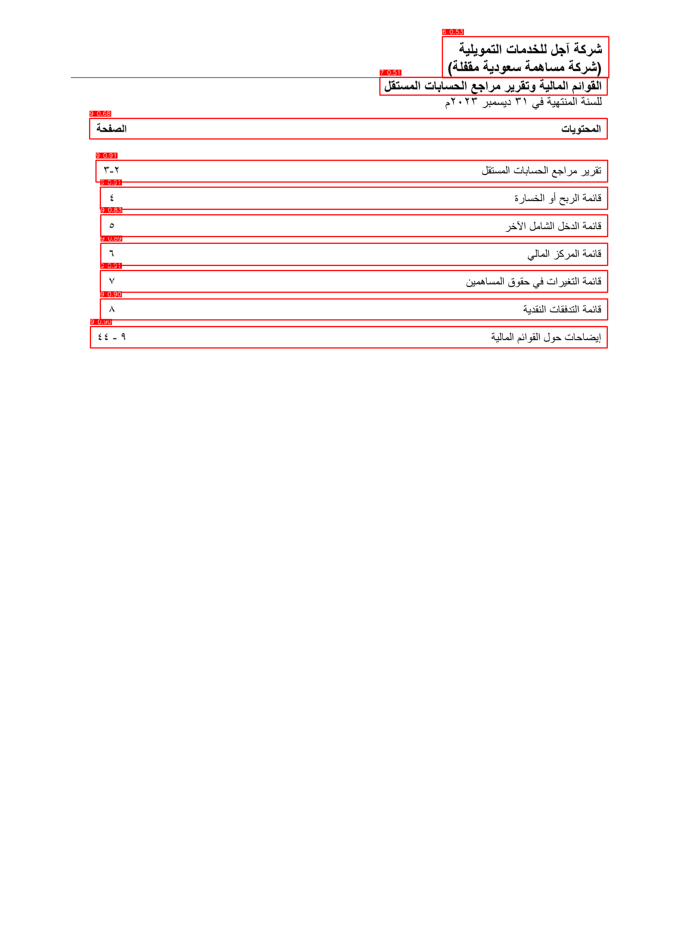

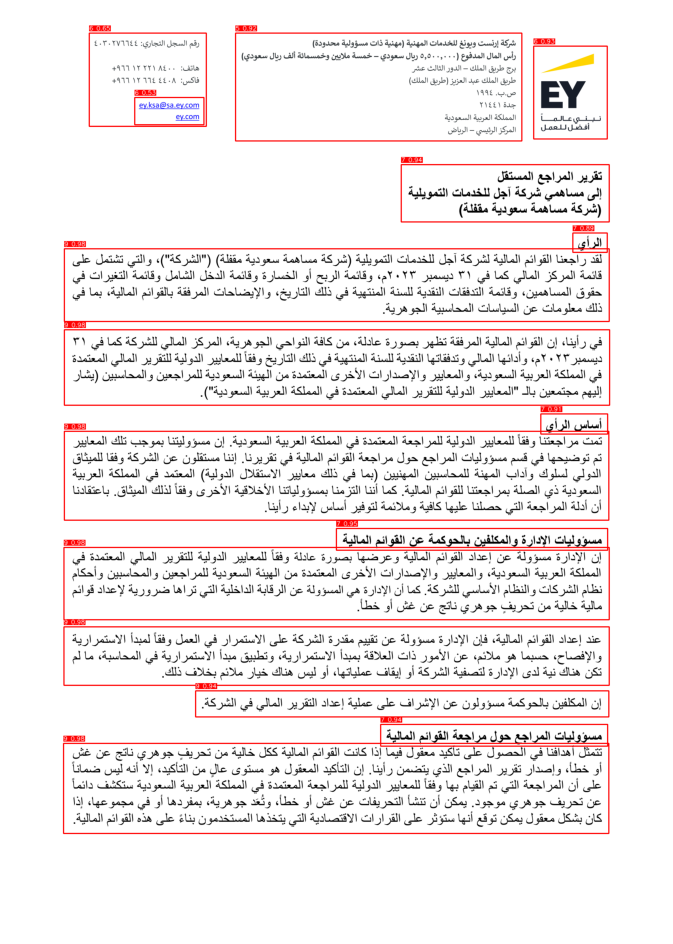

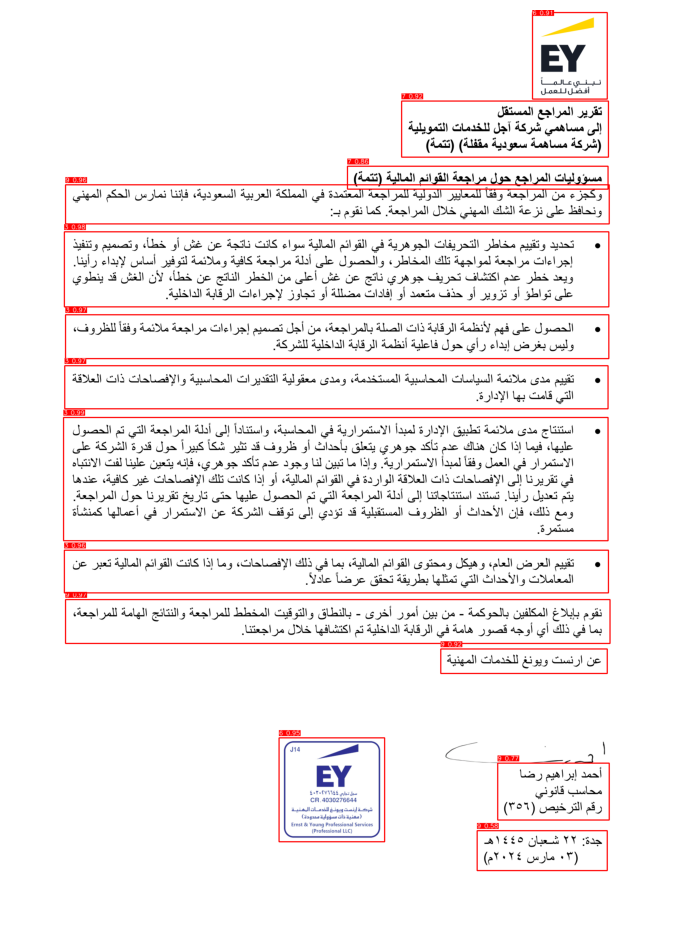

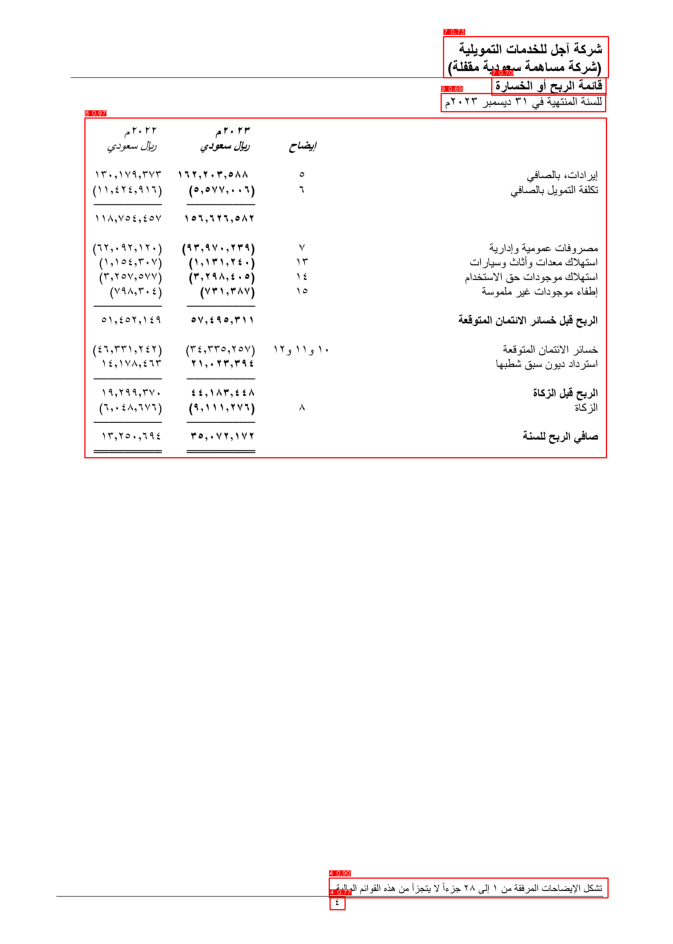

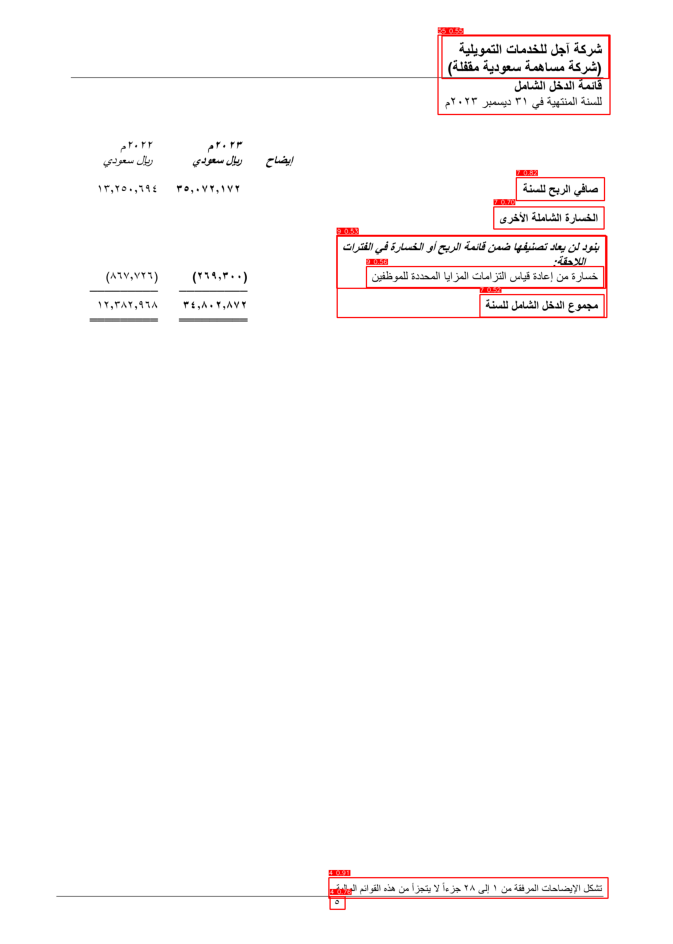

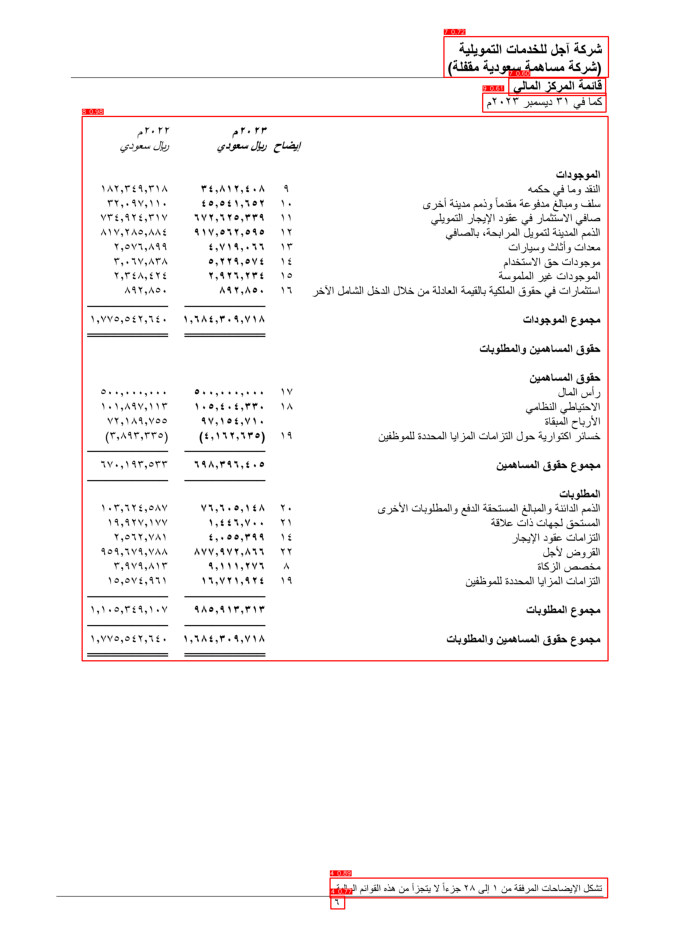

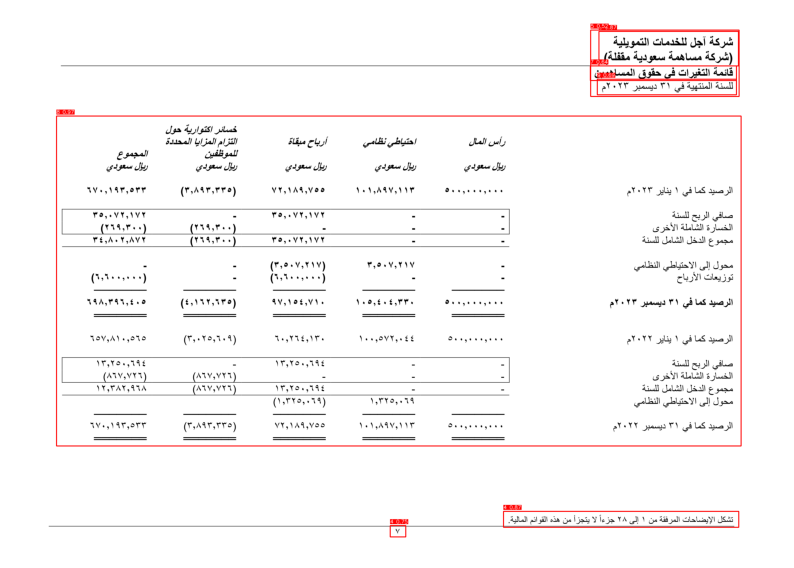

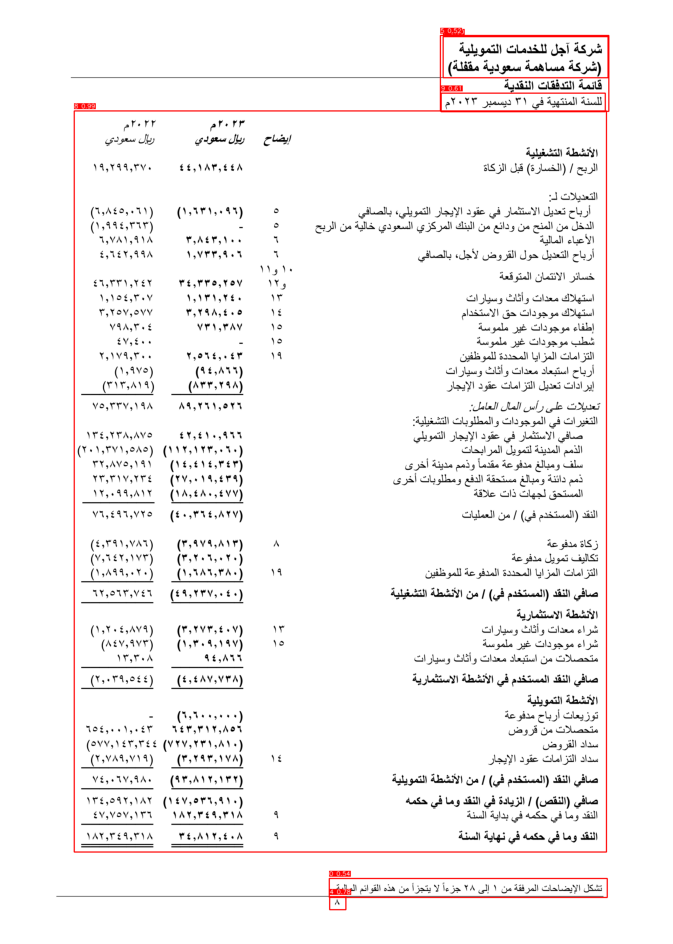

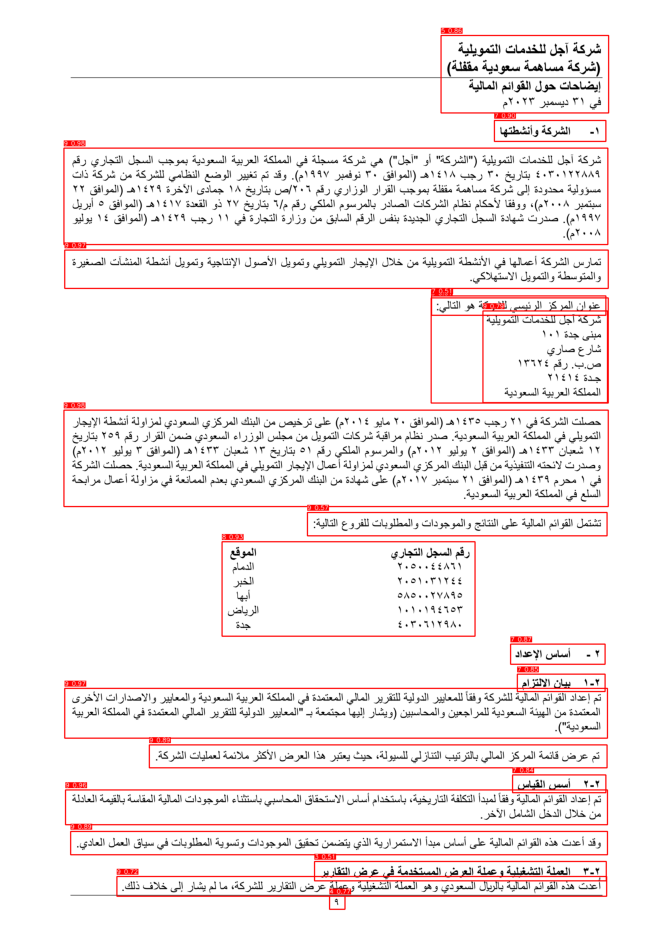

In [7]:
results = run_dfine_on_pdf(model, pdf_path, pages=[0,1,2,3,4,5,6,7,8,9], device=device, conf_thr=0.5)